# Three ways your data can mislead you

This notebook is about some traps that catch researchers
**after** the data are collected: cases where the numbers are perfectly
correct and the *interpretation* is wrong.

1. **Simpson's paradox** — a trend that is true in every subgroup reverses when you pool the data into one big group.
2. **Regression to the mean** — extreme performers drift back toward average, and it looks like some intervention worked.

As before, we simulate a world in which **we secretly know the truth**, so we can
watch the wrong conclusion emerge from correct data.

Throughout, each example is built from three kinds of cell, kept separate on purpose:
**data** cells that create the simulated world, **analysis** cells that compute the
numbers a researcher would report, and **plot** cells that only draw a figure.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets   # interactive buttons

# One random generator with a fixed seed, so everyone gets the same "world".
# Change the seed and re-run everything for different luck same lessons.
rng = np.random.default_rng(11)

# A consistent look for every plot in this notebook
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#3f9b57"
INK, MUTED = "#0b0b0b", "#898781"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 11, "figure.dpi": 110,
})

def fit_line(x, y):
    """Least-squares straight line through the points; returns (slope, intercept).

    np.polyfit with degree 1 fits a straight line y = slope * x + intercept.
    """
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept

## 1. Simpson's paradox

New research question: **does practice improve quality of playing?** We survey the whole
conservatorium every student's weekly practice hours, and assess their performance quality with a jury evaluation.

The truth of our simulated world: within *every* year level, **each extra hour of
weekly practice really adds +1.2 points**. Practice genuinely works, for everyone.

But the levels differ across the years. First-year students are still building technique, spending long hours on
fundamentals while still achieving lower scores. Third-year students have years of accumulated skill:
they achieve higher scores from fewer (more efficient) practice hours.

In [11]:
# ---------- data: three year-level cohorts ----------
# Each cohort: (name, mean weekly practice hours, score baseline, plot colour).
# Practice DECREASES with seniority; the score baseline INCREASES with it.
# That opposite movement is what will produce the paradox.
cohorts = [("1st year", 22, 40, BLUE),
           ("2nd year", 16, 55, GREEN),
           ("3rd year", 10, 70, ORANGE)]
n_cohort = 40

# Within EVERY cohort, one extra hour of practice truly adds this many points:
TRUE_SLOPE = 1.2

practice, score, year = [], [], []
for name, mean_hours, base, _ in cohorts:
    # hours: spread around the cohort's mean (sd 3); nobody below 2 h/week
    hours = rng.normal(mean_hours, 3, n_cohort).clip(min=2)
    practice.append(hours)
    # score: cohort baseline + the true practice effect + luck on the day (sd 4)
    score.append((base + TRUE_SLOPE * hours + rng.normal(0, 4, n_cohort)).clip(max=100))
    year += [name] * n_cohort

# Stack the three cohorts into flat arrays — the researcher receives ONE
# spreadsheet of 120 students, with no year-level column in sight
practice, score, year = np.concatenate(practice), np.concatenate(score), np.array(year)

# ---------- analysis: the pooled trend the researcher reports ----------
r_pooled = np.corrcoef(practice, score)[0, 1]
slope_pooled, int_pooled = fit_line(practice, score)

print(f"Pooled trend: {slope_pooled:+.2f} points per extra hour of practice "
      f"(r = {r_pooled:.2f})")
print(f"Reminder: we BUILT this world so that practice adds "
      f"+{TRUE_SLOPE} points/hour for everyone.")

Pooled trend: -0.65 points per extra hour of practice (r = -0.47)
Reminder: we BUILT this world so that practice adds +1.2 points/hour for everyone.


One hundred and twenty students represented in one scatter plot:

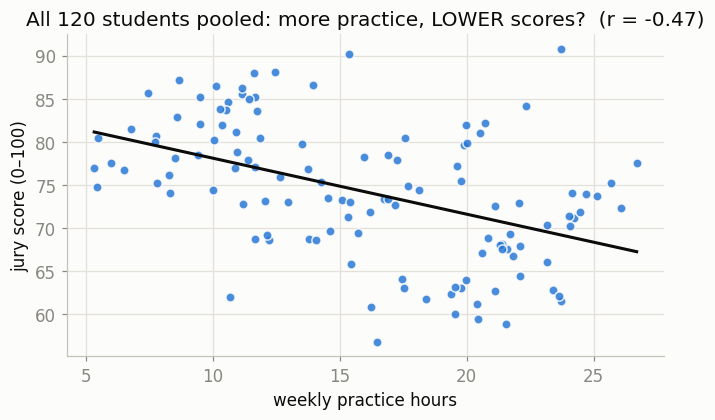

In [12]:
# ---------- plot: all students pooled, as the researcher sees them ----------
fig, ax = plt.subplots(figsize=(7, 3.8))

ax.plot(practice, score, "o", color=BLUE, markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.85)

# the pooled least-squares trend line — it slopes DOWN
xs = np.array([practice.min(), practice.max()])
ax.plot(xs, slope_pooled * xs + int_pooled, color=INK, linewidth=2)

ax.set_xlabel("weekly practice hours")
ax.set_ylabel("jury score (0–100)")
ax.set_title(f"All 120 students pooled: more practice, LOWER scores?  (r = {r_pooled:.2f})")
plt.show()

The pooled data say practice makes you *worse*! The exact opposite of what one would expect (and the opposite of the truth we hard-coded in the simulated world). Before reading on: can you see why?

Run the next cell and click **"reveal the year levels"** to toggle between the
researcher's view and the truth.

In [13]:
# ---------- interactive: toggle between the pooled view and the truth ----------
revealed = {"on": False}
reveal_button = widgets.Button(description="🎓  reveal the year levels",
                               layout=widgets.Layout(width="240px"))
reveal_panel = widgets.Output()

def redraw_reveal():
    with reveal_panel:
        reveal_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 3.8))
        xs = np.array([practice.min(), practice.max()])
        if not revealed["on"]:
            # the researcher's view: one anonymous cloud, one falling trend line
            ax.plot(practice, score, "o", color=BLUE, markersize=6,
                    markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.85)
            ax.plot(xs, slope_pooled * xs + int_pooled, color=INK, linewidth=2)
            ax.set_title(f"Pooled: {slope_pooled:+.2f} points per hour  (r = {r_pooled:.2f})")
        else:
            # the truth: colour by cohort and fit a line INSIDE each one
            ax.plot(xs, slope_pooled * xs + int_pooled, color=MUTED,
                    linewidth=1.5, linestyle="--")   # pooled line kept for contrast
            for name, _, _, color in cohorts:
                mask = year == name
                ax.plot(practice[mask], score[mask], "o", color=color, markersize=6,
                        markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9)
                s, i = fit_line(practice[mask], score[mask])
                xr = np.array([practice[mask].min(), practice[mask].max()])
                ax.plot(xr, s * xr + i, color=color, linewidth=2)
                ax.annotate(f"{name}: {s:+.2f}/h", (xr[1], s * xr[1] + i),
                            color=color, fontsize=10, fontweight="bold",
                            xytext=(8, 0), textcoords="offset points", va="center")
            ax.set_xlim(practice.min() - 1, practice.max() + 6)
            ax.set_title("Within every year level, practice HELPS")
        ax.set_xlabel("weekly practice hours")
        ax.set_ylabel("jury score (0–100)")
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def toggle_reveal(_):
    revealed["on"] = not revealed["on"]
    reveal_button.description = ("🙈  hide the year levels" if revealed["on"]
                                 else "🎓  reveal the year levels")
    redraw_reveal()

reveal_button.on_click(toggle_reveal)
display(widgets.VBox([reveal_button, reveal_panel]))
redraw_reveal()

Here are the numbers broken down by year:

In [14]:
# ---------- analysis: the trend inside each cohort ----------
# cohort_fits maps each cohort name to its fitted (slope, intercept),
# so the plot cell below can reuse them without refitting
cohort_fits = {}

print("Trend in points per extra hour of weekly practice:")
print(f"  all students pooled: {slope_pooled:+.2f}   ← the researcher's view")
for name, _, _, _ in cohorts:
    mask = year == name
    cohort_fits[name] = fit_line(practice[mask], score[mask])
    r_c = np.corrcoef(practice[mask], score[mask])[0, 1]
    print(f"  {name} only:        {cohort_fits[name][0]:+.2f}  (r = {r_c:+.2f})")

Trend in points per extra hour of weekly practice:
  all students pooled: -0.65   ← the researcher's view
  1st year only:        +1.49  (r = +0.74)
  2nd year only:        +1.15  (r = +0.70)
  3rd year only:        +0.98  (r = +0.53)


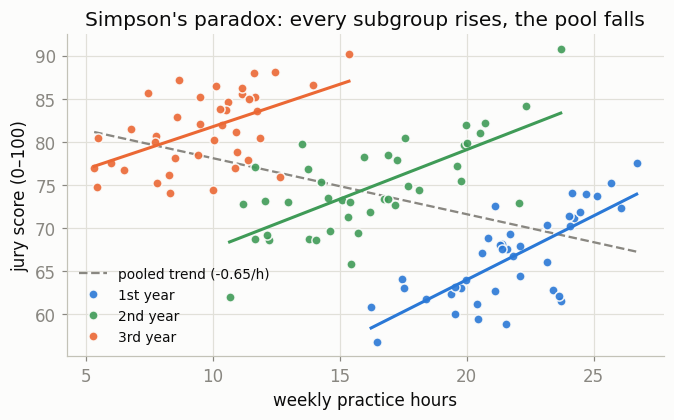

In [15]:
# ---------- plot: every cohort rises while the pool falls ----------
fig, ax = plt.subplots(figsize=(7, 3.8))

# the pooled line, dashed, for contrast
xs = np.array([practice.min(), practice.max()])
ax.plot(xs, slope_pooled * xs + int_pooled, color=MUTED, linewidth=1.5,
        linestyle="--", label=f"pooled trend ({slope_pooled:+.2f}/h)")

# each cohort: its own points and its own rising trend line
for name, _, _, color in cohorts:
    mask = year == name
    ax.plot(practice[mask], score[mask], "o", color=color, markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9, label=name)
    s, i = cohort_fits[name]
    xr = np.array([practice[mask].min(), practice[mask].max()])
    ax.plot(xr, s * xr + i, color=color, linewidth=2)

ax.set_xlabel("weekly practice hours")
ax.set_ylabel("jury score (0–100)")
ax.set_title("Simpson's paradox: every subgroup rises, the pool falls")
ax.legend(frameon=False, fontsize=9)
plt.show()

**What happened.** Year level is associated with *both* variables: senior students
practice fewer hours *and* score higher. Pooling the cohorts lets the between-group
pattern (down-and-to-the-right) overwhelm the within-group pattern (up-and-to-the-
right). Both trends are arithmetically true, but they answer *different questions*:

- *"Do students who practice more score higher?"* -- This is a descriptive question, and the answer is **NO**: heavy-practicers are mostly first-year students who perform worse in absolute terms.
- *"If a given student practices more, will they score higher?"* -- Yes (+1.2 points
  per hour, within every cohort). This is the an inferential question about the hidden causes of the phenomenon, and the pooled plot suggests the wrong answer.

**CORRELATION IS NOT CAUSATION!**

## 3. Regression to the mean — the difficult second album

It is a music-industry proverb that a breakthrough debut is followed by
a disappointing second album. It seems plausible that this might be caused by the pressure of being signed by a major label, possibly having less time to devote to creative work, etc.

 Here we simulate a world were nothing causes the slump, yet the data suggest otherwise when interpreted superficially.

An album's first-month streams are simulated as

$$\text{streams} = \text{quality of the band} + \text{release luck}$$

Luck reflects a playlist placement, a clip that goes viral, a slow news week: all factors that have little to do with the actual quality of the band. Our simulated
scene has **100 new bands**; each band has a certain quality (averaging 250 thousand streams' worth across all bands), and
release luck swings results by about ±90 thousand either way.

After the debut albums come out, two things happen:

- the **20 biggest debuts** are signed by major labels;
- the **20 weakest debuts** fire their managers and hire a new one.

In our simulated world **neither event changes anything**: being signed by a major label does not help the band, nor does hiring a new manager. Streams for the second-album are
the results of the same band quality as the first album, and luck is assigned again at random. 

In [16]:
# ---------- data: 100 bands, two albums each ----------
n_bands = 100

# Band quality, measured in the thousands of streams it is "worth".
# Quality is FIXED — the same on both albums. (.clip stops absurd negatives.)
quality = rng.normal(250, 80, n_bands).clip(min=20)

# Each album's streams = quality + fresh release luck (sd 90k).
# Same `quality` in both lines; only the luck is drawn anew.
debut  = (quality + rng.normal(0, 90, n_bands)).clip(min=5)
second = (quality + rng.normal(0, 90, n_bands)).clip(min=5)

# Select the extremes ON THE DEBUT NUMBERS — this selection is the whole trick.
# np.argsort gives band indices ordered from weakest debut to biggest.
order = np.argsort(debut)
flops, hits = order[:20], order[-20:]

# ---------- analysis: what each group's numbers look like ----------
print("Top 20 debuts (signed by major labels):")
print(f"  debut album mean:  {debut[hits].mean():5.0f}k streams")
print(f"  second album mean: {second[hits].mean():5.0f}k streams   "
      f"→ 'sophomore slump' of {second[hits].mean() - debut[hits].mean():+.0f}k")
print("\nBottom 20 debuts (fired their manager):")
print(f"  debut album mean:  {debut[flops].mean():5.0f}k streams")
print(f"  second album mean: {second[flops].mean():5.0f}k streams   "
      f"→ 'comeback' of {second[flops].mean() - debut[flops].mean():+.0f}k")
print(f"\nWhole roster, both albums: {debut.mean():.0f}k → {second.mean():.0f}k "
      "(nothing changed, as designed)")

Top 20 debuts (signed by major labels):
  debut album mean:    441k streams
  second album mean:   367k streams   → 'sophomore slump' of -74k

Bottom 20 debuts (fired their manager):
  debut album mean:     96k streams
  second album mean:   205k streams   → 'comeback' of +109k

Whole roster, both albums: 262k → 261k (nothing changed, as designed)


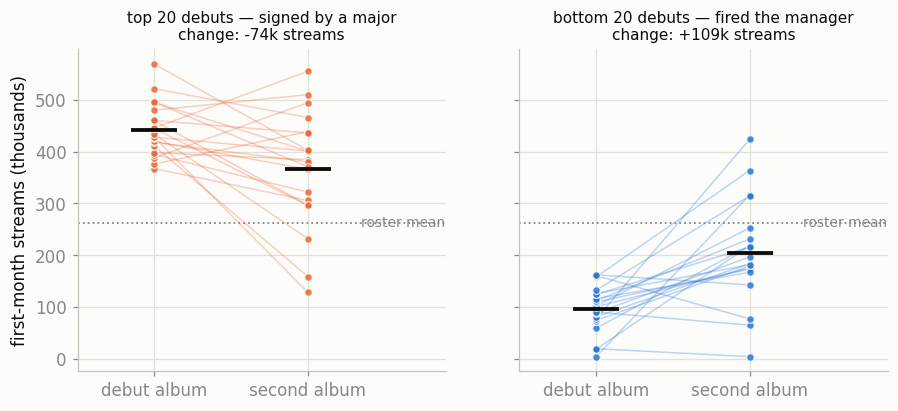

In [17]:
# ---------- plot: debut vs second album for both extreme groups ----------
def draw_release(second_now, note=""):
    """Draw the two before/after panels (top-20 debuts left, bottom-20 right).

    Takes the second-album streams as an argument so the button further down
    can redraw the same picture with freshly drawn luck.
    """
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
    groups = [(axes[0], hits, ORANGE, "top 20 debuts — signed by a major"),
              (axes[1], flops, BLUE, "bottom 20 debuts — fired the manager")]
    for ax, idx, color, label in groups:
        # one line per band, connecting its debut streams to its second-album streams
        for i in idx:
            ax.plot([0, 1], [debut[i], second_now[i]], color=color, alpha=0.3,
                    linewidth=1)
            ax.plot([0, 1], [debut[i], second_now[i]], "o", color=color, markersize=5,
                    markeredgecolor=SURFACE, markeredgewidth=0.8, alpha=0.85)
        # thick black ticks: the group means before and after
        m1, m2 = debut[idx].mean(), second_now[idx].mean()
        ax.hlines(m1, -0.15, 0.15, color=INK, linewidth=2.5)
        ax.hlines(m2, 0.85, 1.15, color=INK, linewidth=2.5)
        # dotted line: the all-roster mean the groups drift back toward
        ax.axhline(debut.mean(), color=MUTED, linewidth=1.2, linestyle=":")
        ax.annotate("roster mean", (1.35, debut.mean()), color=MUTED, fontsize=9,
                    va="center")
        ax.set_xticks([0, 1], ["debut album", "second album"])
        ax.set_xlim(-0.5, 1.9)
        ax.set_title(f"{label}\nchange: {m2 - m1:+.0f}k streams{note}", fontsize=10)
    axes[0].set_ylabel("first-month streams (thousands)")
    plt.show()
    plt.close(fig)   # tidy up when called from a button callback

draw_release(second)

Nothing about the bands changed, yet the bands that were highly successful on their first albums slumped by tens of thousands
of streams, and the bands who fired their manager staged a comeback. The music press has
its headlines ready:

> *"Major-label pressure destroys creativity"*  and *"Firing your manager pays off."*

Both conclusions are pure artefact.

**Why it must happen.** The top 20 were selected *because* their debuts were
extreme, and an extremely big debut usually combines high quality with **good
release luck**. Quality carries over to the second album; the luck does not. Actually, it is almost certain that luck will be lower on a second attempt, dragging their streams back down toward the roster mean (dotted line). The mirror effect lifts the bottom 20%,
whose debut numbers were partly explained by extreme *bad* luck.

Click below to release another round of second albums with fresh luck — the slump
and the comeback both appear every single time, though nothing ever changes.

In [18]:
# ---------- interactive: re-release the second albums with fresh luck ----------
release_rng = np.random.default_rng(99)   # separate generator, fresh luck per click
release = {"k": 0}                        # how many rounds we have run
release_button = widgets.Button(description="🎵  release another second album",
                                layout=widgets.Layout(width="260px"))
release_panel = widgets.Output()

def rerun_release(_):
    release["k"] += 1
    # same band qualities as above — ONLY the release luck is new
    second_new = (quality + release_rng.normal(0, 90, n_bands)).clip(min=5)
    slump = second_new[hits].mean() - debut[hits].mean()
    with release_panel:
        release_panel.clear_output(wait=True)
        print(f"Round #{release['k']}: the 'sophomore slump' struck again — "
              f"{slump:+.0f}k streams for the signed bands")
        draw_release(second_new, note=f"   (round #{release['k']})")

release_button.on_click(rerun_release)
display(widgets.VBox([release_button, release_panel]))